In [2]:
from dotenv import load_dotenv
load_dotenv()

True

In [19]:
from langgraph.graph import START, END, StateGraph
from langchain_groq import ChatGroq
from pydantic import BaseModel, Field
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import InMemorySaver
from typing import Literal

In [4]:
llm = ChatGroq(
    model = 'openai/gpt-oss-20b'
)

In [5]:
class MailState(BaseModel):
    query:str = ''
    draft:str = ''
    human_feedback:str = ''
    final_response:str = ''

In [41]:
# defining the node
def DraftEmail(state:MailState)->MailState:
    if state.human_feedback:
         draft = llm.invoke(f"""
                  rewrite this draft email for {state.query}
                  you have generated this : {state.draft},
                  human feedback to apply : {state.human_feedback},
            """).content
    else:
         draft = llm.invoke(state.query).content

    state.draft = draft
    return state     

def HumanFeedBack(state:MailState)->MailState:
        feedback = interrupt({
            'draft_email':state.draft,
            'question':'do you want to continue or re-write the mail'
        })
        fb = (feedback or "" ).strip().lower()
        if fb in ('approved','ok','yes'):
            state.human_feedback = ""
            return state
        else:
            state.human_feedback = feedback
            return state    
          
def Finalize_node(state:MailState)->MailState:
    if state.human_feedback:
        state.final_response = state.human_feedback
        return state
    else:
        print('email sent successfully')
        state.final_response = 'email sent successfully'
        return state   

def condition_routing(state:MailState)-> Literal['draft','final']:
     if state.human_feedback:
          return 'draft'
     return 'final'
      

In [44]:
# graph creation
graph_builder = StateGraph(MailState)

# nodes

graph_builder.add_node('draft', DraftEmail)
graph_builder.add_node('human_fb', HumanFeedBack)
graph_builder.add_node('final', Finalize_node)

# edge

graph_builder.add_edge(START, 'draft')
graph_builder.add_edge('draft', 'human_fb')
graph_builder.add_conditional_edges('human_fb', condition_routing)
graph_builder.add_edge('final', END)

graph = graph_builder.compile(checkpointer = InMemorySaver())

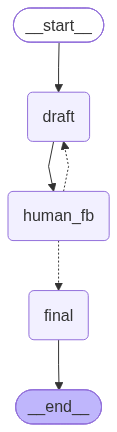

In [45]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

In [46]:
config = {'configurable':{'thread_id':1}}

In [47]:
res = graph.invoke({
    'query':'i want to send a email for medical leave requeste, dates will be second june to 5th june, so create a simple mail'},
    config = config
)

In [48]:
print(res['draft'])

**Subject:** Medical Leave Request – 2 June to 5 June

Dear [Supervisor’s Name],

I am writing to formally request medical leave from **Monday, 2 June** to **Thursday, 5 June**. I will provide a medical certificate upon my return.

I have arranged for [colleague’s name] to cover urgent tasks and will ensure all outstanding work is up to date before my leave. Please let me know if you need any additional information.

Thank you for your understanding.

Kind regards,

[Your Name]  
[Your Position]  
[Your Contact Information]


In [49]:
res = graph.invoke(Command(resume = 'change date from 3 june to 6 june'), config = config)

In [50]:
print(res['draft'])

**Subject:** Medical Leave Request – 3 June to 6 June  

Dear [Supervisor’s Name],

I am writing to request medical leave from **Wednesday, 3 June** through **Saturday, 6 June**. I will provide a medical certificate upon my return.

I have arranged for [Colleague’s Name] to cover urgent tasks and will ensure all outstanding work is up to date before my leave. Please let me know if you need any additional information.

Thank you for your understanding.

Kind regards,  
[Your Name]  
[Your Position]  
[Your Contact Information]
